In [1]:
import pandas as pd
df=pd.read_csv("Loan.csv")
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0  146.412162             360.0   
1             4583             1508.0  128.000000             360.0   
2             3000                0.0   66.000000             360.0   
3             2583             2358.0  120.000000             360.0   
4             6000                0.0  141.000000             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [2]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [3]:
df['Gender'] = df['Gender'].fillna("Male")

In [4]:
df['Married'] = df['Married'].fillna("Yes")

In [5]:
df['Dependents'] = df['Dependents'].fillna(0)

In [6]:
df['Self_Employed'] = df['Self_Employed'].fillna("Yes")

In [7]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [8]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

In [9]:

df['Credit_History'] = df['Credit_History'].fillna(1.0)

In [10]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
df.to_csv("preprocessed_data_1.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


In [12]:
df.to_csv("preprocessed_data_1.csv",index=False)
print("saved")

saved


In [13]:
x = df.drop("LoanAmount",axis=1)
y = df["LoanAmount"]
x = pd.get_dummies(x,drop_first=True)
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",x_train.shape)
print("Testing Features: ",x_test.shape)

print("Training Target: ",y_train.shape)
print("Training Target: ",y_test.shape)
print("Training data")
print(x_train.head())

print("\nTesting data")
print(x_test.head())

Training Features:  (491, 628)
Testing Features:  (123, 628)
Training Target:  (491,)
Training Target:  (123,)
Training data
     ApplicantIncome  CoapplicantIncome  Loan_Amount_Term  Credit_History  \
83              6000             2250.0             360.0             1.0   
90              2958             2900.0             360.0             1.0   
227             6250             1695.0             360.0             1.0   
482             2083             3150.0             360.0             1.0   
464             4166                0.0             360.0             0.0   

     Loan_ID_LP001003  Loan_ID_LP001005  Loan_ID_LP001006  Loan_ID_LP001008  \
83              False             False             False             False   
90              False             False             False             False   
227             False             False             False             False   
482             False             False             False             False   
464             F

In [14]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [15]:
df["ApplicantIncome"]

0      5849
1      4583
2      3000
3      2583
4      6000
       ... 
609    2900
610    4106
611    8072
612    7583
613    4583
Name: ApplicantIncome, Length: 614, dtype: int64

In [16]:
df['LoanAmount']

0      146.412162
1      128.000000
2       66.000000
3      120.000000
4      141.000000
          ...    
609     71.000000
610     40.000000
611    253.000000
612    187.000000
613    133.000000
Name: LoanAmount, Length: 614, dtype: float64

In [17]:
import pandas as pd

df["LoanAmount"] = pd.to_numeric(df["LoanAmount"], errors="coerce")

In [18]:
import numpy as np
X = df['ApplicantIncome']
Y = df['LoanAmount']
m = ((X - X.mean())*(Y - Y.mean()))/((X - X.mean())**2).sum()
c=Y.mean() - m*X.mean()
Y_pred = m*X+c
print(Y_pred)
Y_pred = np.round(Y_pred).astype(int)
print(Y_pred.head())
print("Slope: ",m)
print("Intercept: ",c)

0      146.412162
1      146.411620
2      146.391858
3      146.402978
4      146.412078
          ...    
609    146.391503
610    146.404332
611    146.445340
612    146.420590
613    146.411768
Length: 614, dtype: float64
0    146
1    146
2    146
3    146
4    146
dtype: int64
Slope:  0     -3.152806e-15
1      6.603211e-07
2      8.447960e-06
3      3.256245e-06
4     -1.411251e-07
           ...     
609    8.252305e-06
610    6.035015e-06
611    1.243297e-05
612    3.866823e-06
613    4.810045e-07
Length: 614, dtype: float64
Intercept:  0      146.412162
1      146.408594
2      146.366514
3      146.394567
4      146.412925
          ...    
609    146.367571
610    146.379552
611    146.344981
612    146.391268
613    146.409563
Length: 614, dtype: float64


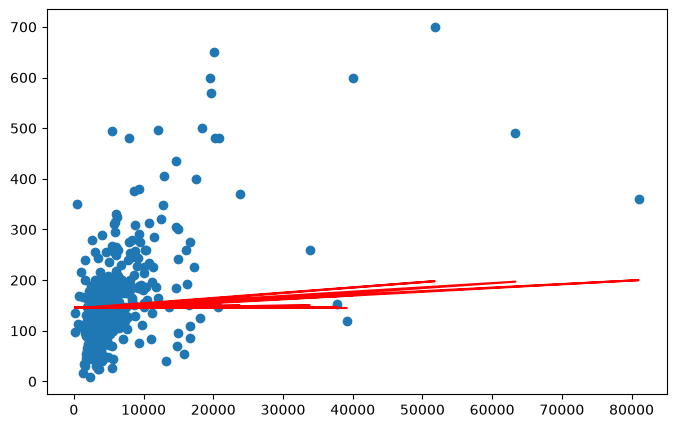

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color = "red")
plt.title = ("simple Linear chart")
plt.xlabel=("Applicant Income")
plt.ylabel=("Loan Amount")
plt.show()

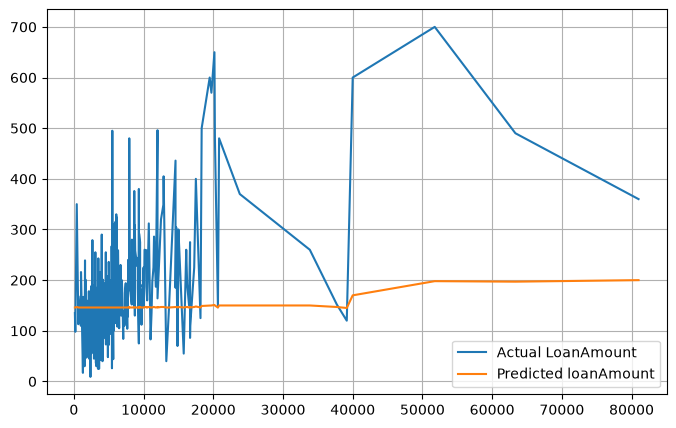

In [20]:
import matplotlib.pyplot as plt
sorted_data = pd.DataFrame({
    "X":X,
    "Actual" : Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(8,5))
plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual LoanAmount")
plt.plot(sorted_data["X"],sorted_data["Predicted"],label="Predicted loanAmount")
plt.title = ("Actual vs Predicted LoanAmount")
plt.xlabel = ("Applicant Income")
plt.ylabel = ("Loan Amount")
plt.legend()
plt.grid(True)
plt.show()

Intercept(b0):  105.27724168201843
Slope(b1):  0.007881588870436803

Regression Equation:
LoanAmount = 105.27724168201843 + 0.007881588870436803 * ApplicantIncome
   ApplicantIncome  Actual LoanAmount  Predicted LoanAmount
0             9083              228.0                   177
1             4310              130.0                   139
2             4167              158.0                   138
3             2900               71.0                   128
4             2718               70.0                   127
5             1782              107.0                   119
6             3717              120.0                   135
7             3000               66.0                   129
8             2647              173.0                   126
9             1000              110.0                   113


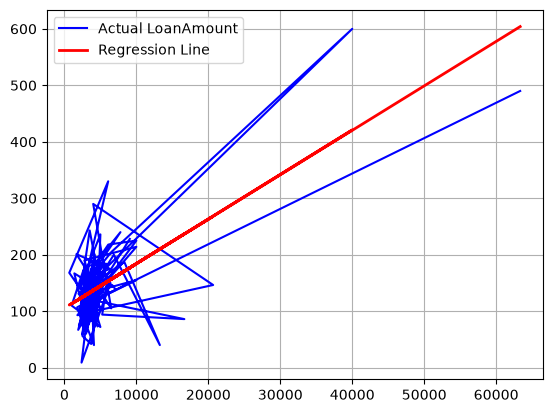

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
df=pd.read_csv(r'preprocessed_data_1.csv')
df.head()

X = df[['ApplicantIncome']]
y = df['LoanAmount']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept(b0): ", model.intercept_)
print("Slope(b1): ", model.coef_[0])
print("\nRegression Equation:")
print(f"LoanAmount = {model.intercept_} + {model.coef_[0]} * ApplicantIncome")
y_pred=model.predict(X_test)
y_pred = np.round(y_pred).astype(int)
result=pd.DataFrame({"ApplicantIncome": X_test["ApplicantIncome"].values,
                    "Actual LoanAmount": y_test.values,
                    "Predicted LoanAmount": y_pred})
print(result.head(10))
plot_data = pd.DataFrame({
    "ApplicantIncome": X_test["ApplicantIncome"].values,
    "Actual LoanAmount": y_test.values,
    "Predicted LoanAmount": y_pred})
plt.plot(
    plot_data["ApplicantIncome"],
    plot_data["Actual LoanAmount"],
    color="blue",
    label="Actual LoanAmount"
)
plt.plot(
    plot_data["ApplicantIncome"],
    plot_data["Predicted LoanAmount"],
    color="red",
    linewidth=2,
    label="Regression Line"
)
plt.title = ("Linear Regression using scikit-learn")
plt.xlabel = ("ApplicantIncome")
plt.ylabel = ("LoanAmount")
plt.legend()
plt.grid(True)
plt.show()